# TMDB — Örnek Kullanım

Bu notebook `src/` modüllerinin nasıl kullanıldığını gösterir.
Yeni bir dataset veya task type ile başlamak için yalnızca **Konfigürasyon** hücresini düzenle.

| Adım | Açıklama |
|------|----------|
| 1 | Kütüphaneler & import |
| 2 | Konfigürasyon |
| 3 | Eğitim |
| 4 | Tuning |
| 5 | Test değerlendirmesi |
| 6 | Rapor |

## 1 — Kütüphaneler

In [21]:
%pip install -q pandas numpy matplotlib mlflow shap lightgbm scikit-learn iterative-stratification ipywidgets optuna

Note: you may need to restart the kernel to use updated packages.


In [22]:
import importlib
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

import src.modeling, src.evaluation, src.tuning, src.reporting, src.automl
for _mod in (src.modeling, src.evaluation, src.tuning, src.reporting, src.automl):
    importlib.reload(_mod)

from src.modeling import MAIN_METRIC, train_session, compare_models
from src.evaluation import evaluate_test
from src.tuning import tune_model
from src.reporting import generate_experiment_report

RANDOM_STATE = 42
print('✓ Hazır')

✓ Hazır


## 2 — Konfigürasyon

In [23]:
# ── Yeni bir proje için yalnızca bu hücreyi düzenle ───────────
DATASET_PATH     = 'data/tmdb_model.csv'
TASK_TYPE        = 'binary'   # binary | multiclass | regression | timeseries | multilabel
TARGET           = 'hit'
N_TRIALS         = 50
FEATURE_PREFIXES = ['genre_', 'kw_']
FEATURE_VERSION  = 'v4_univariate_selected'  # 49→30 özellik: Bonferroni + multikolinearite drop

BASE_FEATURES = [
    # Bütçe & Prodüksiyon
    'budget', 'runtime',
    'num_companies',
    'is_major_studio', 'is_english', 'is_us_production',
    # Pazarlama
    'has_homepage',
    # Tür & Franchise
    'num_genres', 'is_franchise',
    # Takvim
    'is_summer', 'is_holiday',
    # Yönetmen & Oyuncu geçmişi (temporal safe)
    'director_film_count', 'director_collab_count',
    'director_hist_roi', 'actor_hist_roi',
    # Bütçe verimliliği (temporal safe)
    'relative_budget_score',
]
# ──────────────────────────────────────────────────────────────


### Feature Seçimi

**Kural:** Modelde yalnızca filmin vizyona girmesinden **önce** kesin olarak bilinen özellikler kullanılır.

#### Kullanılan Özellikler (28 adet) — v4 Univariate Seçimi

| Grup | Sayı | Özellikler |
|------|------|-----------|
| Sayısal / meta | 9 | `budget`, `runtime`, `num_companies`, `num_genres`, `director_film_count`, `director_collab_count`, `director_hist_roi`, `actor_hist_roi`, `relative_budget_score` |
| Binary — yapısal | 7 | `is_major_studio`, `is_english`, `is_us_production`, `has_homepage`, `is_summer`, `is_holiday`, `is_franchise` |
| Binary — tür | 9 | `genre_Action`, `genre_Adventure`, `genre_Animation`, `genre_Documentary`, `genre_Drama`, `genre_Family`, `genre_Fantasy`, `genre_Horror`, `genre_Science Fiction` |
| Binary — keyword | 3 | `kw_3d`, `kw_sequel`, `kw_independent_film` |

**Notlar:**
- `director_film_count` / `director_collab_count` / `director_hist_roi` / `actor_hist_roi` — temporal safe: her film için yalnızca `release_date` öncesi filmler kullanılır
- `relative_budget_score` — temporal safe: filmin türlerinin geçmiş bütçe ortalamasına oranı
- `is_summer` = Haziran–Ağustos vizyonu; `is_holiday` = Kasım–Aralık vizyonu

#### Çıkarılan Özellikler

| Özellik | Gerekçe |
|---------|--------|
| `popularity`, `vote_average`, `vote_count` | Post-release — film izlendikten sonra TMDB'de oluşur |
| `has_postcredit` | Post-release — filmin izlenmesini gerektirir |
| `budget_log` | `budget` zaten mevcut; log dönüşümü tree modeller için gereksiz |
| `budget_per_minute` | Multikolinearite: `budget` ile r=0.969 |
| `tagline_length`, `overview_length`, `num_countries`, `num_languages` | Bonferroni anlamsız (p > 0.0010) |
| `kw_based_on_novel`, `kw_woman_director`, `kw_biography`, `kw_musical` | Bonferroni anlamsız (p > 0.0010) |
| 10 genre özelliği | Bonferroni anlamsız: `genre_Romance`, `genre_Crime`, `genre_History`, `genre_Western`, `genre_Mystery`, `genre_Comedy`, `genre_War`, `genre_Foreign`, `genre_Thriller`, `genre_Music` |
| `kw_aftercreditsstinger`, `kw_duringcreditsstinger` | Post-release — SHAP analizi: zayıf sinyal (mean_abs < 0.007), kullanıcılar izledikten sonra etiketler |
| `kw_murder`, `kw_dystopia`, vb. | Post-release — kullanıcıların film izledikten sonra eklediği içerik etiketleri |


### Veri Hazırlama *(dokunma)*

In [24]:
EXPERIMENT_NAME = Path(DATASET_PATH).stem
MLFLOW_URI = os.getenv('MLFLOW_TRACKING_URI', 'http://localhost:5000')
mlflow.set_tracking_uri(MLFLOW_URI)

df          = pd.read_csv(DATASET_PATH)
prefix_cols = [c for c in df.columns if any(c.startswith(p) for p in FEATURE_PREFIXES)]
FEATURES    = BASE_FEATURES + prefix_cols

df_model = df[FEATURES + [TARGET]]
X        = df_model[FEATURES]
y        = df_model[TARGET]

if TASK_TYPE == 'timeseries':
    n = len(X)
    X_train = X.iloc[:int(n * 0.70)]
    X_val   = X.iloc[int(n * 0.70):int(n * 0.85)]
    X_test  = X.iloc[int(n * 0.85):]
    y_train = y.iloc[:int(n * 0.70)]
    y_val   = y.iloc[int(n * 0.70):int(n * 0.85)]
    y_test  = y.iloc[int(n * 0.85):]
else:
    stratify = y if TASK_TYPE in ('binary', 'multiclass') else None
    # 3-way split: 70 / 15 / 15
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, stratify=stratify, random_state=RANDOM_STATE,
    )
    val_frac = 0.15 / 0.85  # ~17.6% of temp → ~15% of total
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_frac,
        stratify=y_temp if TASK_TYPE in ('binary', 'multiclass') else None,
        random_state=RANDOM_STATE,
    )

print(f'Dataset  : {DATASET_PATH}')
print(f'Task     : {TASK_TYPE}')
print(f'Toplam   : {len(df_model):,}  |  hit oranı: %{y.mean()*100:.1f}')
print(f'Train    : {len(X_train):,}  (~70%)')
print(f'Val      : {len(X_val):,}  (~15%) — hibrit seçimi')
print(f'Test     : {len(X_test):,}  (~15%) — yalnızca final raporu')
print(f'Özellik  : {len(FEATURES)}')

Dataset  : data/tmdb_model.csv
Task     : binary
Toplam   : 3,226  |  hit oranı: %34.8
Train    : 2,258  (~70%)
Val      : 484  (~15%) — hibrit seçimi
Test     : 484  (~15%) — yalnızca final raporu
Özellik  : 28


## 3 — Baseline Eğitimi

Eğitim başlıyor  —  experiment: "tmdb_model"  |  oturum: session_A_20260425_1837  |  task: binary


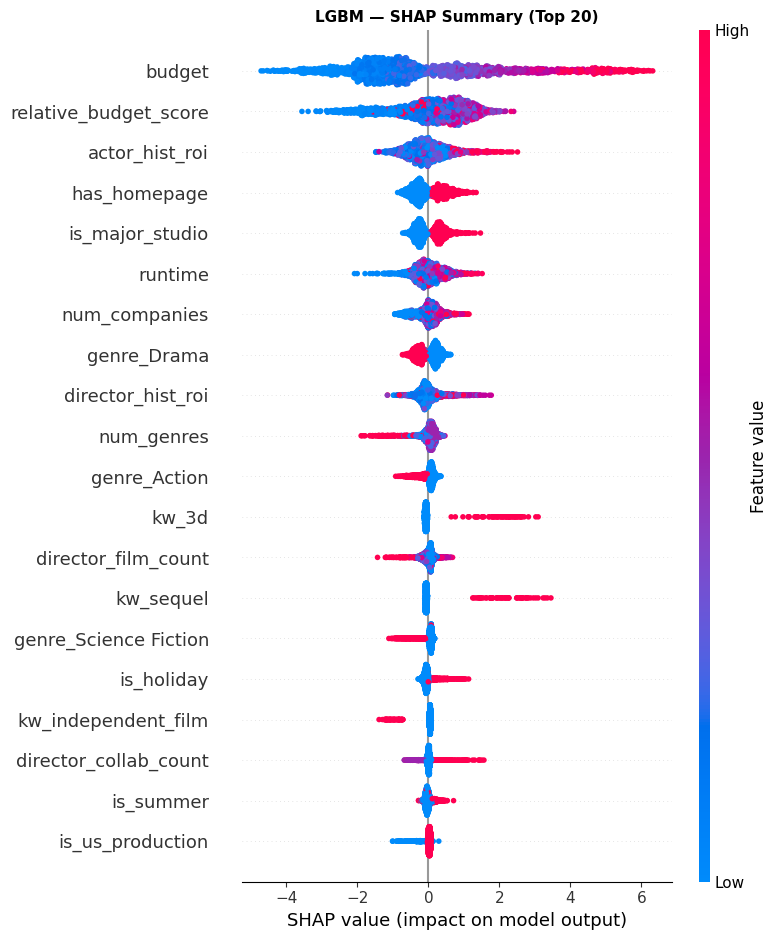

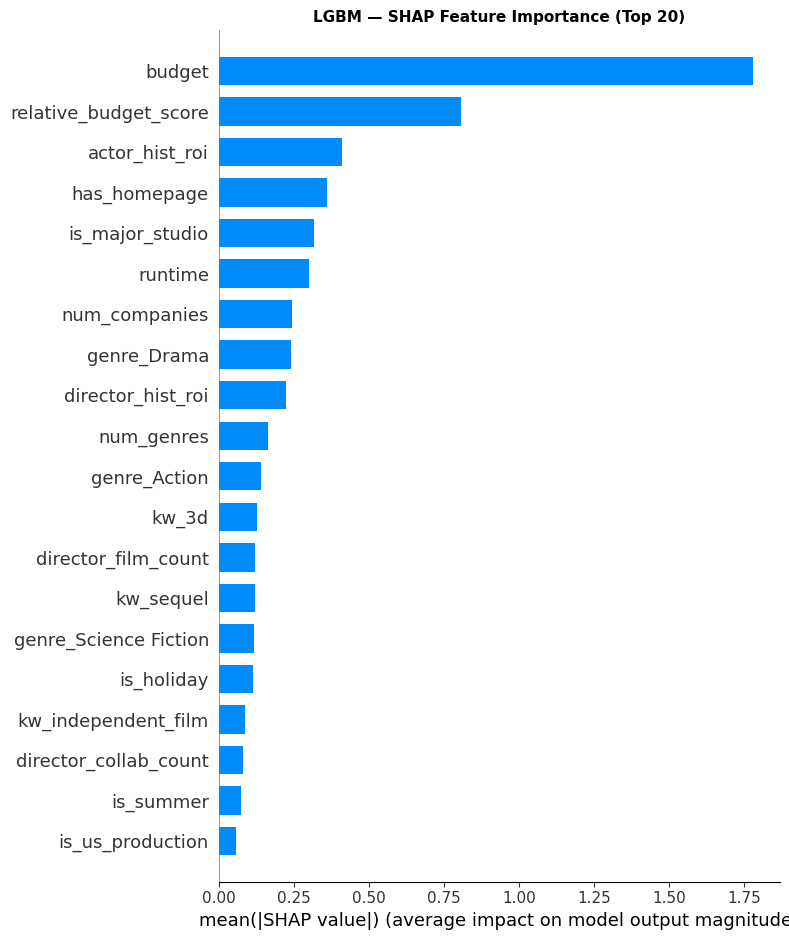

  ✓ baseline_lgbm_20260425_1837                        train=1.000  val=0.769  gap=+0.231
🏃 View run baseline_lgbm_20260425_1837 at: http://localhost:5000/#/experiments/1/runs/09e08271b9d1445fb5083cb7e1783561
🧪 View experiment at: http://localhost:5000/#/experiments/1


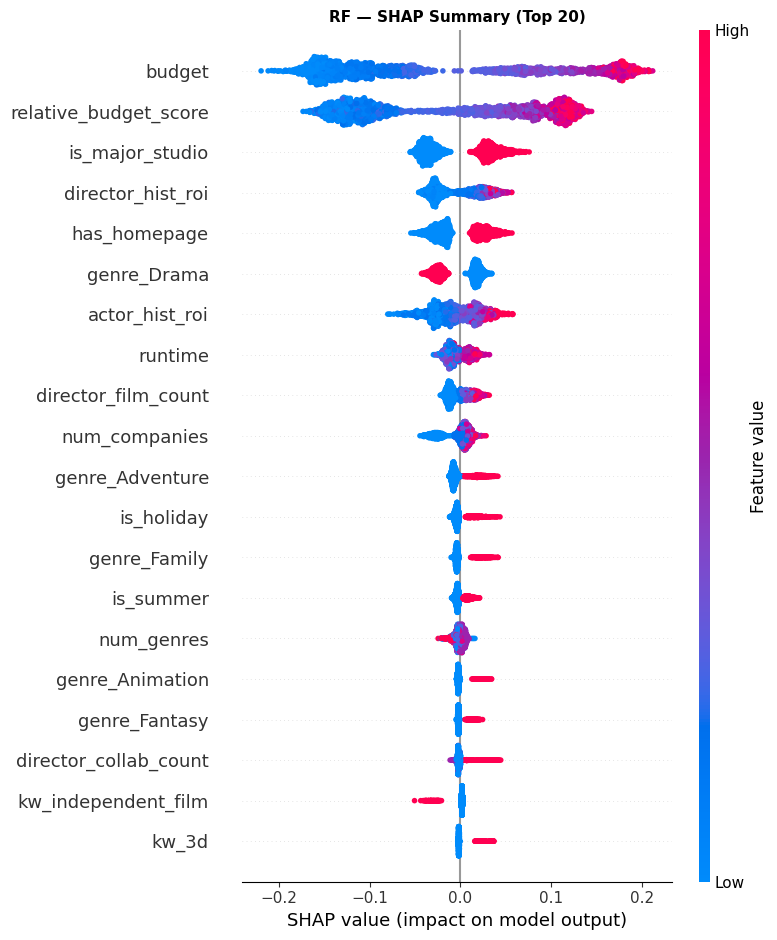

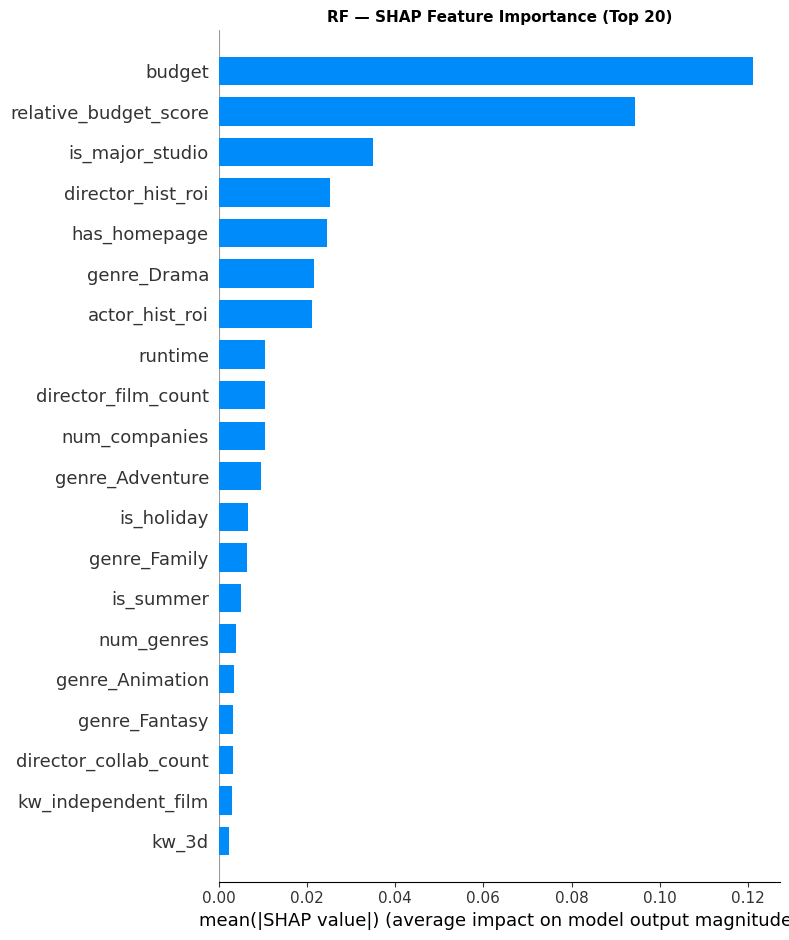

  ✓ baseline_rf_20260425_1838                          train=0.875  val=0.783  gap=+0.092
🏃 View run baseline_rf_20260425_1838 at: http://localhost:5000/#/experiments/1/runs/b57dc30a04dc4c6fb62022539ec8ce3d
🧪 View experiment at: http://localhost:5000/#/experiments/1


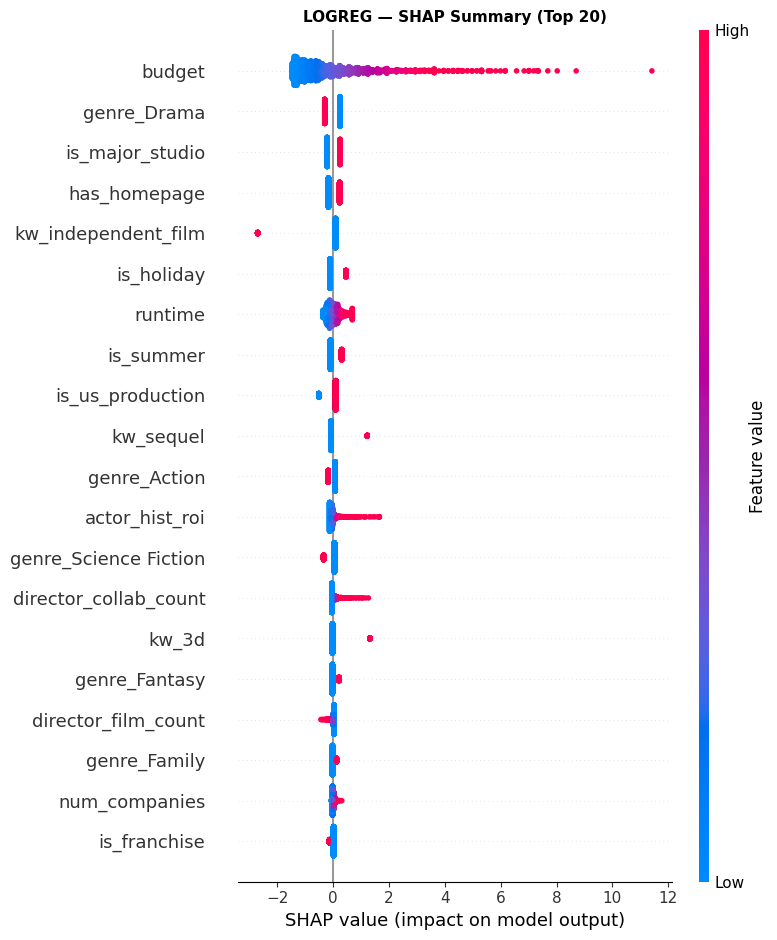

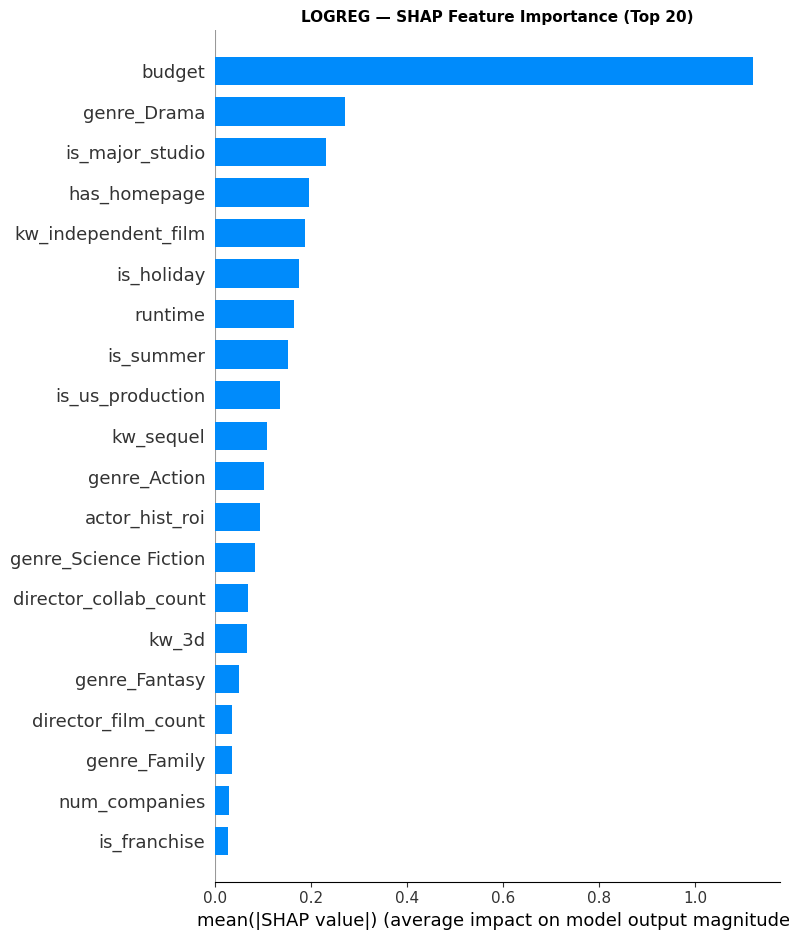

  ✓ baseline_logreg_20260425_1838                      train=0.795  val=0.782  gap=+0.013
🏃 View run baseline_logreg_20260425_1838 at: http://localhost:5000/#/experiments/1/runs/82149de8f747496b98e8a5a4c93ed7f5
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run session_A_20260425_1837 at: http://localhost:5000/#/experiments/1/runs/6087f0baaf70426882e159c2b868b413
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ Oturum tamamlandı


In [25]:
MODEL_CONFIGS = {
    'lgbm': lambda ir: LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, scale_pos_weight=ir,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=1,
    ),
    'rf': lambda ir: RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1,
    ),
    'logreg': lambda ir: Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1, class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ]),
}

models, results = train_session(
    DATASET_PATH, MODEL_CONFIGS, X_train, y_train,
    task_type=TASK_TYPE, scenario='A',
)

=== Model Karşılaştırma Tablosu ===


,ROC_AUC,F1,PRECISION,RECALL,AVG_PREC
Model,,,,,
lgbm,0.842,0.687,0.727,0.653,0.769
rf,0.853,0.704,0.673,0.739,0.783
logreg,0.855,0.698,0.676,0.723,0.782



🏆 En iyi model: rf  (avg_prec=0.783)
🏃 View run comparison_chart at: http://localhost:5000/#/experiments/1/runs/3adfab573f84481bb2eea56bd73521ab
🧪 View experiment at: http://localhost:5000/#/experiments/1


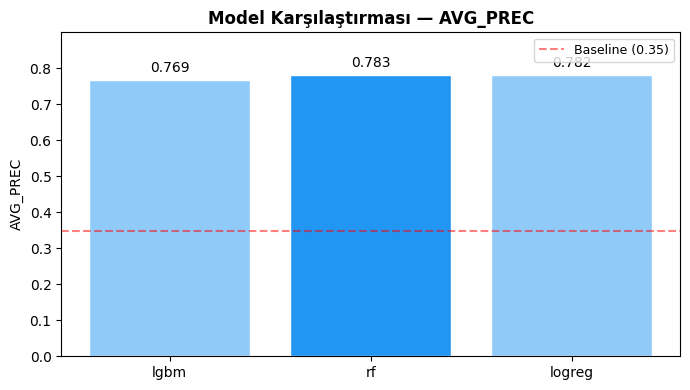


=== Overfitting / Underfitting Analizi ===


,Train AVG_PREC,Val AVG_PREC,Gap (Train−Val)
Model,,,
lgbm,1.000,0.769,0.231
rf,0.875,0.783,0.092
logreg,0.795,0.782,0.013


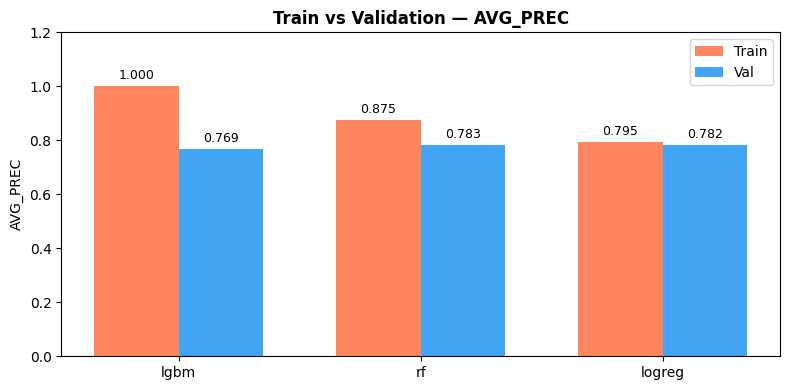

  ⚠️  lgbm: ciddi overfit (gap=0.231 > 0.2) — dışlandı
  ✓ Geçerli modeller: ['rf', 'logreg'] — en iyi: rf


In [26]:
main_metric = MAIN_METRIC[TASK_TYPE]
best        = compare_models(results, TASK_TYPE, EXPERIMENT_NAME, y_train)
best_model  = models[best]

## 4 — Hiperparametre Tuning (Tüm Modeller)

In [27]:
from src.automl import tune_all_models

best_model, best, tuned_models, ensemble_candidates = tune_all_models(
    results           = results,
    X                 = X_train,
    y                 = y_train,
    task_type         = TASK_TYPE,
    n_trials          = N_TRIALS,
    max_gap           = 0.10,
    X_val             = X_val,
    y_val             = y_val,
    jaccard_threshold = 0.60,
    feature_version   = FEATURE_VERSION,
)

if ensemble_candidates:
    print(f"\nEnsemble adayları: {list(ensemble_candidates.keys())}")


── Tuning: rf  (baseline=0.7825  min_improvement=0.0229) ──
Optuna başlıyor — model: rf  |  metrik: avg_prec  |  trial: 50  |  max_gap: 0.1


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  avg_prec: 0.7825
  Tuned     avg_prec: 0.7852
  İyileşme : +0.0027

  En iyi parametreler:
    n_estimators: 198
    max_depth: 16
    min_samples_leaf: 10
    max_features: sqrt
  Train-val gap: 0.0917  (✓ eşik altı)
✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_rf_20260425_1839 at: http://localhost:5000/#/experiments/1/runs/4255ca46071442ba8881f055484fb4b6
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned rf
  — rf: iyileşme yetersiz (+0.0027 < 0.0229) — elendi

── Tuning: logreg  (baseline=0.7823  min_improvement=0.0254) ──
Optuna başlıyor — model: logreg  |  metrik: avg_prec  |  trial: 50  |  max_gap: 0.1


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  avg_prec: 0.7823
  Tuned     avg_prec: 0.7830
  İyileşme : +0.0007

  En iyi parametreler:
    C: 1.5402560025307634
  Train-val gap: 0.0122  (✓ eşik altı)
✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_logreg_20260425_1840 at: http://localhost:5000/#/experiments/1/runs/2fcbf1d135bc4ccc9b42c9364c451b61
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned logreg
  — logreg: iyileşme yetersiz (+0.0007 < 0.0254) — elendi

⚠️  Recovery tuning: ['lgbm']  (eşik=0.2)

── Recovery Tuning: lgbm ──
Optuna başlıyor — model: lgbm  |  metrik: avg_prec  |  trial: 50  |  max_gap: 0.1


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  avg_prec: 0.7688
  Tuned     avg_prec: 0.7817
  İyileşme : +0.0129

  En iyi parametreler:
    n_estimators: 346
    learning_rate: 0.01050600834210248
    num_leaves: 33
    min_child_samples: 73
    reg_alpha: 0.0001092636906677507
    reg_lambda: 0.016422714663410182
    subsample: 0.5372300635135263
    colsample_bytree: 0.7221369130608308
  Train-val gap: 0.0825  (✓ eşik altı)
✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_lgbm_20260425_1840 at: http://localhost:5000/#/experiments/1/runs/70c63b8ed2d34d0f953187fc2a7bf52c
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned lgbm
  — lgbm: recovery tamamlandı (0.7817 ≤ 0.7852) — best model değişmedi

✓ tune_all_models tamamlandı — best: rf  (avg_prec=0.7852)

── Ensemble Aday Analizi (Jaccard eşik=0.6) ──
  rf ↔ logreg: Jaccard=0.71 → atlandı (>0.6)
  rf ↔ lgbm: Jaccard=0.86 → atlandı (>0.6)
  Yeterli çeşitlilik yok — ensemble önerilmiyor.


## 5 — Test Değerlendirmesi

              precision    recall  f1-score   support

           0       0.85      0.80      0.83       315
           1       0.67      0.75      0.71       169

    accuracy                           0.78       484
   macro avg       0.76      0.77      0.77       484
weighted avg       0.79      0.78      0.79       484


=== Test Metrikleri ===
  PR-AUC      : 0.8093
  ROC-AUC     : 0.8697
  F1          : 0.7059
  Precision   : 0.6702
  Recall      : 0.7456

=== RF — CV vs Test Karşılaştırması ===


,CV (val),Test,Fark
PR-AUC,0.783,0.809,0.026
ROC-AUC,0.853,0.870,0.017
F1,0.704,0.706,0.002
Precision,0.673,0.670,-0.003
Recall,0.739,0.746,0.007


🏃 View run test_eval_rf_20260425_1840 at: http://localhost:5000/#/experiments/1/runs/e47471a4a0fa4707b5a992a45e822ed8
🧪 View experiment at: http://localhost:5000/#/experiments/1
✓ Test metrikleri MLflow'a kaydedildi


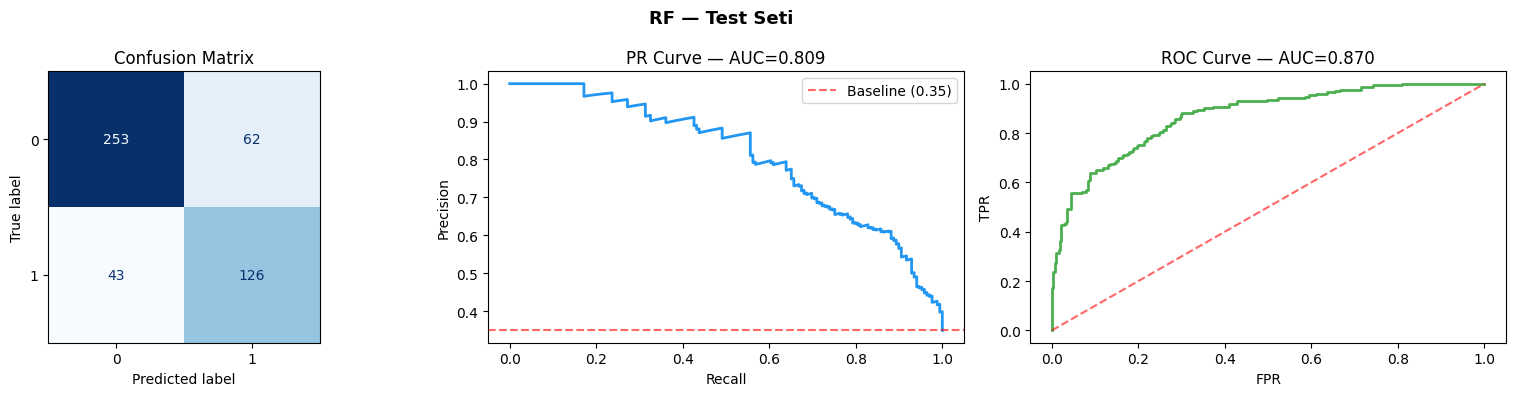

In [28]:
test_metrics = evaluate_test(
    best_model, X_test, y_test, TASK_TYPE, best,
    cv_metrics      = results[best]['val'],
    experiment_name = EXPERIMENT_NAME,
    feature_version = FEATURE_VERSION,
    features        = FEATURES,
    extra_tags      = {"selection_method": "val_based"},
)


## 6 — Rapor

In [29]:
from IPython.display import Markdown, display

report = generate_experiment_report(
    experiment_name = EXPERIMENT_NAME,
    task_type       = TASK_TYPE,
    dataset_path    = DATASET_PATH,
    n_samples       = len(df_model),
    hit_rate        = y.mean(),
    n_features      = len(FEATURES),
)

display(Markdown(report))

✓ Rapor oluşturuldu → experiment_report_20260425_184047.md
✓ MLflow'a kaydedildi → docs/experiment_report_20260425_184047.md
🏃 View run report_20260425_1840 at: http://localhost:5000/#/experiments/1/runs/1fbe84fc18b34aa7a644c564d91d9050
🧪 View experiment at: http://localhost:5000/#/experiments/1


# Experiment Raporu — tmdb_model

**Oluşturulma:** 2026-04-25 18:40  
**Task:** binary  
**Ana Metrik:** avg_prec  
**Dataset:** data/tmdb_model.csv  
**Toplam Film:** 3,226  |  **Hit Oranı:** %34.8  
**Özellik Sayısı:** 28  

---

## Baseline Sonuçları

| Model | PR-AUC | ROC-AUC | F1 | Precision | Recall |
|-------|--------|---------|----|-----------|----|
| logreg | 0.782 | 0.855 | 0.698 | 0.676 | 0.723 |
| rf | 0.783 | 0.853 | 0.704 | 0.673 | 0.739 |
| lgbm | 0.769 | 0.842 | 0.687 | 0.727 | 0.653 |

---

## Tuning

- **lgbm** — Baseline avg_prec: 0.769 → Tuned: 0.782 (İyileşme: 0.013)
- **logreg** — Baseline avg_prec: 0.782 → Tuned: 0.783 (İyileşme: 0.001)
- **rf** — Baseline avg_prec: 0.783 → Tuned: 0.785 (İyileşme: 0.003)

---

## Test Seti Sonuçları

| Metrik | Değer |
|--------|-------|
| RECALL | 0.746 |
| ROC_AUC | 0.870 |
| PRECISION | 0.670 |
| PR_AUC | 0.809 |
| F1 | 0.706 |

## 7 — Hibrit Modeller

Baseline modellerin (LGBM, RF, LogReg) güçlü yönlerini birleştirmek için üç strateji deneniyor.

| Yöntem | Fikir | Artısı | Eksi |
|--------|-------|--------|------|
| **Voting** | Olasılıkların ağırlıklı ortalaması | Basit, hızlı, yorumlanabilir | Modeller aynı hatayı paylaşabilir |
| **Stacking** | CV ile out-of-fold meta-özellik → meta-model | En güçlü kombinasyon | Yavaş, dikkatli CV gerektirir |
| **Blending** | Holdout meta-özellik → meta-model (CV yok) | Hızlı, leakage riski düşük | Daha az veri verimli |

In [30]:
import numpy as np
from sklearn.base import clone
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, precision_score, recall_score

ir = (y_train == 0).sum() / (y_train == 1).sum()

def make_lgbm():
    return LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, scale_pos_weight=ir,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=1,
    )

def make_rf():
    return RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1,
    )

def make_logreg():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1, class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ])

def quick_val_metrics(model, X, y):
    """Val/test seti için sızıntısız metrik hesabı — MLflow kaydı yok."""
    proba = model.predict_proba(X)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    return {
        "PR-AUC":    average_precision_score(y, proba),
        "ROC-AUC":   roc_auc_score(y, proba),
        "F1":        f1_score(y, pred, zero_division=0),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall":    recall_score(y, pred, zero_division=0),
    }

print(f'✓ Base model factory hazır  |  imbalance_ratio: {ir:.3f}')
print('✓ quick_val_metrics hazır')

✓ Base model factory hazır  |  imbalance_ratio: 1.873
✓ quick_val_metrics hazır


### 7a — Voting Ensemble

`VotingClassifier(voting='soft')` her modelin olasılık tahminlerini ağırlıklı ortalamayla birleştirir.
LGBM baseline'da en güçlü performansı gösterdiği için `weights=[2, 1, 1]` kullanıyoruz.

In [31]:
# Top-2 seçimi: val avg_prec sıralaması
ranked = sorted(
    tuned_models.keys(),
    key=lambda name: results.get(name, {}).get("val", {}).get("avg_prec", 0),
    reverse=True,
)[:2]

scores  = {name: results[name]["val"]["avg_prec"] for name in ranked}
weights = [scores[name] for name in ranked]

print(f"Voting top-2 : {ranked}")
print(f"Weights      : {[f'{w:.4f}' for w in weights]}")

voting_clf = VotingClassifier(
    estimators=[(name, clone(tuned_models[name])) for name in ranked],
    voting="soft",
    weights=weights,
    n_jobs=1,
)
voting_clf.fit(X_train, y_train)
voting_val_metrics = quick_val_metrics(voting_clf, X_val, y_val)
print(f"Val PR-AUC   : {voting_val_metrics['PR-AUC']:.4f}")

# Top-3: tüm tuned modeller
ranked3  = sorted(
    tuned_models.keys(),
    key=lambda name: results.get(name, {}).get("val", {}).get("avg_prec", 0),
    reverse=True,
)
scores3  = {name: results[name]["val"]["avg_prec"] for name in ranked3}
weights3 = [scores3[name] for name in ranked3]

print(f"\nVoting top-3 : {ranked3}")
print(f"Weights      : {[f'{w:.4f}' for w in weights3]}")

voting3_clf = VotingClassifier(
    estimators=[(name, clone(tuned_models[name])) for name in ranked3],
    voting="soft",
    weights=weights3,
    n_jobs=1,
)
voting3_clf.fit(X_train, y_train)
voting3_val_metrics = quick_val_metrics(voting3_clf, X_val, y_val)
print(f"Val PR-AUC   : {voting3_val_metrics['PR-AUC']:.4f}")

Voting top-2 : ['rf', 'logreg']
Weights      : ['0.7825', '0.7823']
Val PR-AUC   : 0.8041

Voting top-3 : ['rf', 'logreg', 'lgbm']
Weights      : ['0.7825', '0.7823', '0.7688']
Val PR-AUC   : 0.8047


### 7b — Stacking

`StackingClassifier` her base modeli 5-fold CV ile eğitip out-of-fold tahminlerini
meta-özellik olarak kullanır. Meta-model (LogisticRegression) bu özelliklerden öğrenir.

In [32]:
stacking_clf = StackingClassifier(
    estimators=[
        ('lgbm',   clone(tuned_models['lgbm'])),
        ('rf',     clone(tuned_models['rf'])),
        ('logreg', clone(tuned_models['logreg'])),
    ],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=1,
)
stacking_clf.fit(X_train, y_train)
stacking_val_metrics = quick_val_metrics(stacking_clf, X_val, y_val)
print(f"Stacking Val PR-AUC: {stacking_val_metrics['PR-AUC']:.4f}")

Stacking Val PR-AUC: 0.8040


### 7c — Blending

Train setinin %20'si **holdout** olarak ayrılır. Base modeller kalan %80 üzerinde eğitilir;
holdout tahminleri meta-model için girdi oluşturur. Stacking'e kıyasla daha hızlı ama
daha az veri verimlidir.

In [33]:
class BlendingEnsemble:
    """
    Blending stratejisi:
      1. X_train → blend_train (%80) + holdout (%20) olarak bölünür.
      2. Base modeller yalnızca blend_train üzerinde eğitilir.
      3. Holdout tahminleri (predict_proba) meta-özellik matrisini oluşturur.
      4. Meta-model bu matris üzerinde eğitilir.
      5. Test tahminleri: base modeller test setini tahmin eder → meta-model birleştirir.

    Stacking'den farkı: CV yoktur; bilgi sızıntısını önlemek için ayrı bir holdout kullanılır.
    """

    def __init__(self, base_models: list, meta_model, blend_ratio: float = 0.2,
                 random_state: int = 42):
        self.base_models  = base_models   # [(isim, estimator), ...]
        self.meta_model   = meta_model
        self.blend_ratio  = blend_ratio
        self.random_state = random_state

    def fit(self, X, y):
        from sklearn.model_selection import train_test_split
        X_bt, X_hold, y_bt, y_hold = train_test_split(
            X, y,
            test_size=self.blend_ratio,
            stratify=y,
            random_state=self.random_state,
        )
        for _, m in self.base_models:
            m.fit(X_bt, y_bt)

        meta_train = np.column_stack([
            m.predict_proba(X_hold)[:, 1] for _, m in self.base_models
        ])
        self.meta_model.fit(meta_train, y_hold)
        return self

    def predict_proba(self, X):
        meta = np.column_stack([
            m.predict_proba(X)[:, 1] for _, m in self.base_models
        ])
        prob1 = self.meta_model.predict_proba(meta)[:, 1]
        return np.column_stack([1 - prob1, prob1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

print('✓ BlendingEnsemble sınıfı tanımlandı')

✓ BlendingEnsemble sınıfı tanımlandı


In [34]:
blending_clf = BlendingEnsemble(
    base_models=[(name, clone(tuned_models[name])) for name in tuned_models],
    meta_model=LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    blend_ratio=0.2,
    random_state=RANDOM_STATE,
)
blending_clf.fit(X_train, y_train)
blending_val_metrics = quick_val_metrics(blending_clf, X_val, y_val)
print(f"Blending Val PR-AUC: {blending_val_metrics['PR-AUC']:.4f}")

Blending Val PR-AUC: 0.8047


### Tüm Hibrit Modellerin Karşılaştırması

=== Hibrit Model Karşılaştırması (Val Seti — Sızıntısız) ===


,PR-AUC,ROC-AUC,F1,Precision,Recall
Model,,,,,
best_single (rf),0.8012,0.8589,0.7263,0.6878,0.7692
voting_top2,0.8041,0.8604,0.7242,0.6842,0.7692
voting_top3,0.8047,0.8590,0.7403,0.6943,0.7929
stacking,0.8040,0.8586,0.7015,0.7308,0.6746
blending,0.8047,0.8595,0.7003,0.7500,0.6568


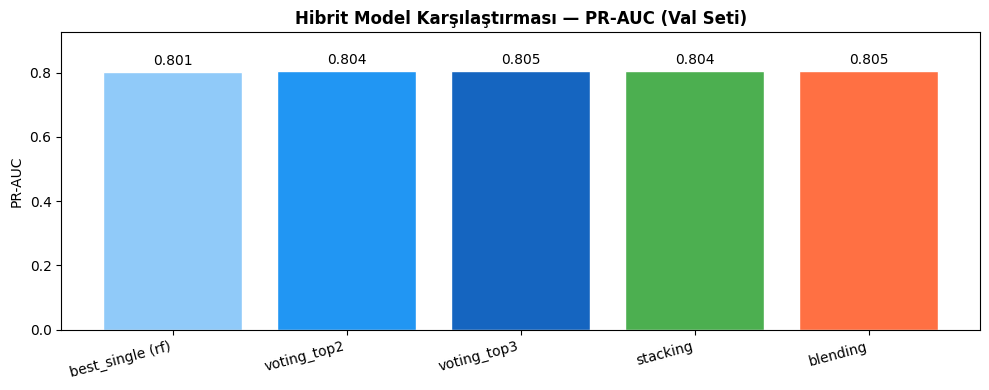

In [35]:
metric_col = "PR-AUC"
best_single_val_metrics = quick_val_metrics(best_model, X_val, y_val)

hybrid_val_results = {
    f"best_single ({best})": best_single_val_metrics,
    "voting_top2":           voting_val_metrics,
    "voting_top3":           voting3_val_metrics,
    "stacking":              stacking_val_metrics,
    "blending":              blending_val_metrics,
}

rows = []
for name, m in hybrid_val_results.items():
    rows.append({"Model": name, **{k: round(v, 4) for k, v in m.items()}})
comparison_df = pd.DataFrame(rows).set_index("Model")
print("=== Hibrit Model Karşılaştırması (Val Seti — Sızıntısız) ===")
display(comparison_df)

vals   = [m.get(metric_col, 0) for m in hybrid_val_results.values()]
labels = list(hybrid_val_results.keys())
colors = ["#90CAF9", "#2196F3", "#1565C0", "#4CAF50", "#FF7043"]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, vals, color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=10)
ax.set_title(f"Hibrit Model Karşılaştırması — {metric_col} (Val Seti)", fontsize=12, fontweight="bold")
ax.set_ylim(0, max(vals) * 1.15)
ax.set_ylabel(metric_col)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Final Model Seçimi

=== Final Model (val seti seçimi — sızıntısız) ===
  Model       : voting_top3
  Val PR-AUC : 0.8047

              precision    recall  f1-score   support

           0       0.87      0.80      0.83       315
           1       0.68      0.78      0.72       169

    accuracy                           0.79       484
   macro avg       0.77      0.79      0.78       484
weighted avg       0.80      0.79      0.79       484


=== Test Metrikleri ===
  PR-AUC      : 0.8139
  ROC-AUC     : 0.8728
  F1          : 0.7218
  Precision   : 0.6753
  Recall      : 0.7751

=== VOTING_TOP3 — CV vs Test Karşılaştırması ===


,CV (val),Test,Fark
PR-AUC,0.783,0.814,0.031
ROC-AUC,0.853,0.873,0.020
F1,0.704,0.722,0.018
Precision,0.673,0.675,0.002
Recall,0.739,0.775,0.036


🏃 View run test_eval_voting_top3_20260425_1840 at: http://localhost:5000/#/experiments/1/runs/ecaa8ac426c64e54a83b0e2f059de940
🧪 View experiment at: http://localhost:5000/#/experiments/1
✓ Test metrikleri MLflow'a kaydedildi


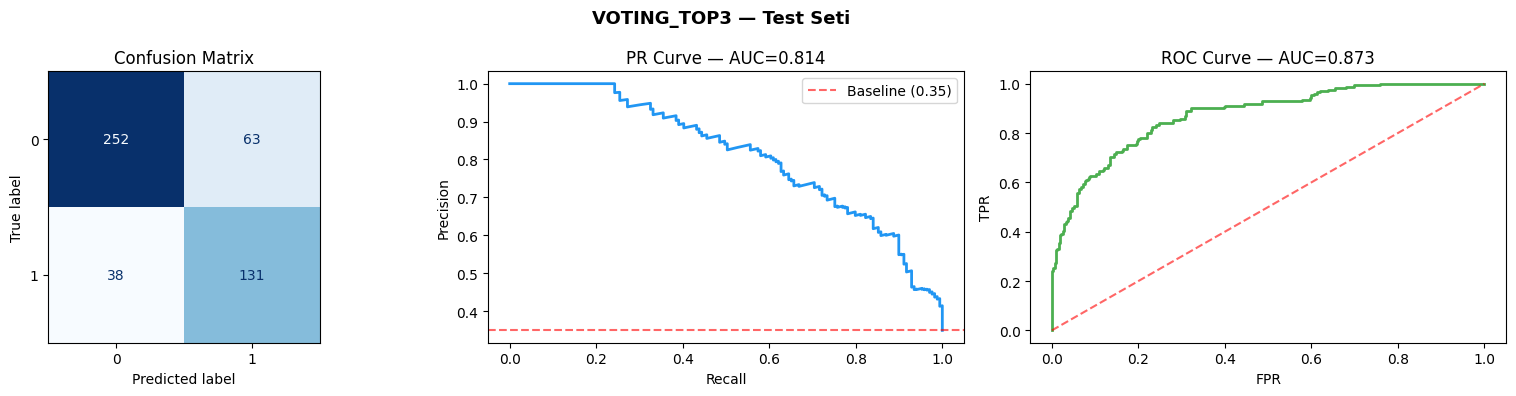

=== Test Skoru (yalnızca seçilen model) ===
  PR-AUC      : 0.8139
  ROC-AUC     : 0.8728
  F1          : 0.7218
  Precision   : 0.6753
  Recall      : 0.7751


In [36]:
all_candidates = {
    f"best_single ({best})": (best_model,   best_single_val_metrics),
    "voting_top2":           (voting_clf,   voting_val_metrics),
    "voting_top3":           (voting3_clf,  voting3_val_metrics),
    "stacking":              (stacking_clf, stacking_val_metrics),
    "blending":              (blending_clf, blending_val_metrics),
}

main_metric_key = "PR-AUC"
final_name  = max(all_candidates, key=lambda n: all_candidates[n][1].get(main_metric_key, 0))
final_model = all_candidates[final_name][0]
final_val   = all_candidates[final_name][1]

print("=== Final Model (val seti seçimi — sızıntısız) ===")
print(f"  Model       : {final_name}")
print(f"  Val {main_metric_key} : {final_val[main_metric_key]:.4f}")
print()

# evaluate_test yalnızca seçilen model için X_test üzerinde çağrılır
if "best_single" in final_name:
    final_metrics = test_metrics  # cell 2b97424c'de hesaplandı
else:
    final_metrics = evaluate_test(
        final_model, X_test, y_test, TASK_TYPE,
        final_name.replace(" ", "_").replace("(", "").replace(")", ""),
        cv_metrics      = results[best]["val"],
        experiment_name = EXPERIMENT_NAME,
        feature_version = FEATURE_VERSION,
        extra_tags      = {"selection_method": "val_based"},
    )

print("=== Test Skoru (yalnızca seçilen model) ===")
for k, v in final_metrics.items():
    print(f"  {k:<12}: {v:.4f}")


In [37]:
import json, tempfile
from collections import defaultdict
from mlflow.tracking import MlflowClient

client = MlflowClient()
exp    = client.get_experiment_by_name(EXPERIMENT_NAME)

if exp:
    eid = exp.experiment_id

    # ── Champion Tracking ────────────────────────────────────────────
    # Yalnızca val_based seçim metoduyla kaydedilen run'lar — leaky_test etiketliler hariç
    val_based_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string=(
            f"tags.stage = 'test' "
            f"AND tags.feature_version = '{FEATURE_VERSION}' "
            f"AND tags.selection_method = 'val_based'"
        ),
        order_by=["metrics.test_pr_auc DESC"],
    )

    curr_score = final_metrics.get('PR-AUC', 0)

    if val_based_runs:
        champion   = val_based_runs[0]
        hist_score = champion.data.metrics.get('test_pr_auc', 0)
        delta      = curr_score - hist_score
        symbol     = "Yeni şampiyon!" if delta > 0 else "Geçilemedi"
        print("=== Champion Tracking (val_based) ===")
        print(f"  Geçmiş en iyi  : {hist_score:.4f}  ({champion.info.run_name})")
        print(f"  Mevcut         : {curr_score:.4f}  ({final_name})")
        print(f"  Fark           : {delta:+.4f}  — {symbol}")

        artifact_names = {a.path for a in client.list_artifacts(champion.info.run_id)}
        if "features.json" in artifact_names:
            try:
                with tempfile.TemporaryDirectory() as tmp:
                    path = client.download_artifacts(champion.info.run_id, "features.json", tmp)
                    with open(path) as f:
                        hist_features = set(json.load(f)["features"])
                curr_features = set(FEATURES)
                added   = sorted(curr_features - hist_features)
                removed = sorted(hist_features - curr_features)
                print(f"\n=== Feature Karşılaştırması ===")
                print(f"  Geçmiş : {len(hist_features)} feature")
                print(f"  Mevcut : {len(curr_features)} feature")
                if added:
                    print(f"  Eklenen  (+{len(added)}): {', '.join(added)}")
                if removed:
                    print(f"  Çıkarılan (-{len(removed)}): {', '.join(removed)}")
                if not added and not removed:
                    print("  Feature seti değişmedi.")
            except Exception:
                pass
        else:
            print("\n  (Geçmiş şampiyonda features.json yok — karşılaştırma atlandı)")
    else:
        champion = None
        print("=== Champion Tracking (val_based) ===")
        print(f"  İlk val_based run — referans skor: {curr_score:.4f}  ({final_name})")
        print(f"  Feature sayısı: {len(FEATURES)}")

    # ── Genel MLflow Temizliği ────────────────────────────────────────

    # 1. Tüm test run'ları çek; leaky_test ve şampiyon korunur, diğerleri silinir
    all_test_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string="tags.stage = 'test'",
        order_by=["metrics.test_pr_auc DESC"],
    )
    champion_id = champion.info.run_id if champion else None
    stale_test  = [
        r for r in all_test_runs
        if r.info.run_id != champion_id
        and r.data.tags.get("selection_method") != "leaky_test"
    ]
    for r in stale_test:
        client.delete_run(r.info.run_id)
    if stale_test:
        print(f"\n✓ {len(stale_test)} eski test run'ı silindi — şampiyon ve leaky_test korundu")

    # 2. Summary, report, session — türetilmiş bilgi, tümünü sil
    for run_type in ("summary", "report", "session"):
        to_del = list(client.search_runs(
            experiment_ids=[eid],
            filter_string=f"tags.type = '{run_type}'",
        ))
        for r in to_del:
            client.delete_run(r.info.run_id)
        if to_del:
            print(f"✓ {len(to_del)} {run_type} run'ı silindi")

    # 3. Tuning — model başına en yüksek skoru koru (tüm era dahil)
    tuning_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string="tags.type = 'tuning'",
        order_by=["metrics.tuned_avg_prec DESC"],
    )
    by_model = defaultdict(list)
    for r in tuning_runs:
        by_model[r.data.tags.get("model_type", "unknown")].append(r)

    tuning_deleted = 0
    for runs in by_model.values():
        for r in runs[1:]:
            client.delete_run(r.info.run_id)
            tuning_deleted += 1
    if tuning_deleted:
        print(f"✓ {tuning_deleted} eski tuning run'ı silindi — model başına 1 korundu")

    # 4. Baseline — model başına en son run'ı koru (tüm era dahil)
    baseline_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string="tags.type = 'baseline'",
        order_by=["start_time DESC"],
    )
    by_model_bl = defaultdict(list)
    for r in baseline_runs:
        by_model_bl[r.data.tags.get("model_type", "unknown")].append(r)

    baseline_deleted = 0
    for runs in by_model_bl.values():
        for r in runs[1:]:
            client.delete_run(r.info.run_id)
            baseline_deleted += 1
    if baseline_deleted:
        print(f"✓ {baseline_deleted} eski baseline run'ı silindi — model başına 1 korundu")

    # 5. Bilinmeyen tip run'lar (feature_selection vb.) — tümünü sil
    known_types  = {"test_evaluation", "tuning", "baseline", "summary", "report", "session"}
    all_runs     = client.search_runs(experiment_ids=[eid])
    other_deleted = 0
    for r in all_runs:
        tags      = r.data.tags
        run_type  = tags.get("type", "")
        run_stage = tags.get("stage", "")
        is_known  = run_type in known_types or run_stage == "test"
        if not is_known and r.info.run_id != champion_id:
            client.delete_run(r.info.run_id)
            other_deleted += 1
    if other_deleted:
        print(f"✓ {other_deleted} diğer run silindi (feature_selection vb.)")

else:
    print(f"MLflow experiment '{EXPERIMENT_NAME}' bulunamadı.")


=== Champion Tracking (val_based) ===
  Geçmiş en iyi  : 0.8153  (test_eval_voting_top3_20260425_0125)
  Mevcut         : 0.8139  (voting_top3)
  Fark           : -0.0014  — Geçilemedi

  (Geçmiş şampiyonda features.json yok — karşılaştırma atlandı)

✓ 2 eski test run'ı silindi — şampiyon ve leaky_test korundu
✓ 1 summary run'ı silindi
✓ 1 report run'ı silindi
✓ 1 session run'ı silindi
✓ 3 eski tuning run'ı silindi — model başına 1 korundu
✓ 3 eski baseline run'ı silindi — model başına 1 korundu


## 8 — SHAP Analizi

`voting_top3` modelinin LightGBM bileşeni üzerinden her özelliğin katkı yönü ve büyüklüğü hesaplanıyor.

**Kontrol listesi:**

| Soru | Özellik |
|---|---|
| Leakage riski var mı? | `kw_aftercreditsstinger`, `kw_duringcreditsstinger` |
| Budget ile çakışıyor mu? | `relative_budget_score` vs `budget` |
| Tarihsel sinyal güçlü mü? | `director_hist_roi`, `actor_hist_roi` |


In [38]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# SHAP analizi için her zaman voting3_clf kullan (v4 hedef modeli)
_shap_clf = voting3_clf
_lgbm = _shap_clf.named_estimators_.get(
    'lgbm',
    next(
        est for name, est in zip(
            [n for n, _ in _shap_clf.estimators],
            _shap_clf.estimators_
        )
        if 'lightgbm' in str(type(est)).lower()
    )
)

explainer  = shap.TreeExplainer(_lgbm)
shap_raw   = explainer.shap_values(X_test)

# Binary sınıflandırma: list[class0, class1] veya tek array
if isinstance(shap_raw, list):
    sv = shap_raw[1]   # hit sınıfı katkıları
else:
    sv = shap_raw

feature_names = X_test.columns.tolist()
mean_abs = np.abs(sv).mean(axis=0)
mean_val = sv.mean(axis=0)

shap_df = pd.DataFrame({
    'feature'       : feature_names,
    'mean_abs_shap' : mean_abs,
    'mean_shap'     : mean_val,
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_df['direction'] = shap_df['mean_shap'].apply(
    lambda x: '↑ hit' if x > 0 else '↓ miss'
)

print("=== SHAP Global Önem — voting_top3 / LightGBM (Top-20) ===")
display(shap_df[['feature', 'direction', 'mean_abs_shap', 'mean_shap']].head(20).round(4))


=== SHAP Global Önem — voting_top3 / LightGBM (Top-20) ===


,feature,direction,mean_abs_shap,mean_shap
0,budget,↓ miss,0.9185,-0.0202
1,relative_budget_score,↑ hit,0.4260,0.0107
2,is_major_studio,↑ hit,0.1833,0.0026
3,has_homepage,↑ hit,0.1829,0.0140
4,num_companies,↑ hit,0.1407,0.0073
5,genre_Drama,↑ hit,0.1397,0.0133
6,actor_hist_roi,↓ miss,0.1205,-0.0164
7,director_hist_roi,↓ miss,0.0722,-0.0158
8,is_holiday,↑ hit,0.0633,0.0022
9,runtime,↓ miss,0.0562,-0.0012


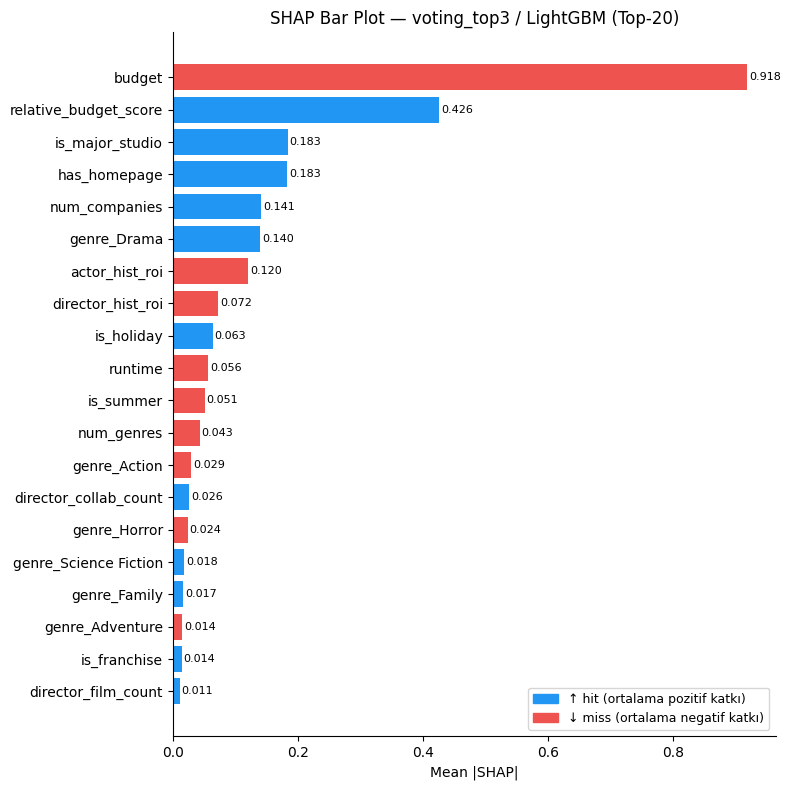

In [39]:
fig, ax = plt.subplots(figsize=(8, 8))
top_n = 20
df_plot = shap_df.head(top_n).sort_values('mean_abs_shap')

colors = ['#2196F3' if d == '↑ hit' else '#EF5350' for d in df_plot['direction']]
bars = ax.barh(df_plot['feature'], df_plot['mean_abs_shap'], color=colors)

for bar, val in zip(bars, df_plot['mean_abs_shap']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#2196F3', label='↑ hit (ortalama pozitif katkı)'),
    Patch(color='#EF5350', label='↓ miss (ortalama negatif katkı)'),
], loc='lower right', fontsize=9)

ax.set_xlabel('Mean |SHAP|')
ax.set_title('SHAP Bar Plot — voting_top3 / LightGBM (Top-20)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


In [40]:
print("=== Leakage & Çakışma Kontrol ===\n")

# Bilinen post-release feature'lar — film izlendikten veya yayınlandıktan sonra oluşur.
# Buraya eklenen her feature modelde varsa otomatik olarak leakage olarak raporlanır.
POST_RELEASE_FEATURES = {
    # TMDB kullanıcı aktivitesi
    'popularity', 'vote_average', 'vote_count',
    # Film izlenmesini gerektiren özellikler
    'has_postcredit',
    # Post-credit sahnesi tag'leri — kullanıcılar izledikten sonra ekler
    'kw_aftercreditsstinger', 'kw_duringcreditsstinger',
    # İzleyici yorumuna dayalı içerik etiketleri
    'kw_murder', 'kw_dystopia', 'kw_rape', 'kw_nudity',
    'kw_violence', 'kw_torture', 'kw_suicide',
}

OVERLAP_CORR_THRESHOLD = 0.70
HIST_ROI_PATTERN       = '_hist_roi'

num_features    = [f for f in feature_names if X_test[f].nunique() > 2]

# ── 1. Leakage: whitelist kontrolü ──────────────────────────────────────────
in_model     = [f for f in POST_RELEASE_FEATURES if f in feature_names]
already_drop = [f for f in POST_RELEASE_FEATURES if f not in feature_names]

print(f"Leakage Kontrolü — {len(POST_RELEASE_FEATURES)} bilinen post-release feature\n")

if in_model:
    print("  ⚠️  Modelde post-release feature var:")
    for feat in in_model:
        idx       = feature_names.index(feat)
        rank      = shap_df[shap_df['feature'] == feat].index[0] + 1
        mas       = float(np.abs(sv[:, idx]).mean())
        shap_hit  = sv[y_test.values == 1, idx].mean()
        shap_miss = sv[y_test.values == 0, idx].mean()
        print(f"    {feat:<35}  #{rank:<3}  mean_abs={mas:.4f}  "
              f"shap_hit={shap_hit:+.4f}  shap_miss={shap_miss:+.4f}")
    print(f"\n  → Aksiyon: bu {len(in_model)} feature'ı BASE_FEATURES veya tmdb_model.csv'den çıkarın.")
else:
    print("  ✅  Modelde bilinen post-release feature yok.")

print(f"\n  (Modelde yer almayan post-release feature: {len(already_drop)} adet — bunların büyük çoğunluğu BASE_FEATURES'e hiç alınmadı)")  

# ── 2. Çakışma: continuous feature'lar arası SHAP korelasyonu ───────────────
print(f"\nSHAP Korelasyon Matrisi (eşik |r| > {OVERLAP_CORR_THRESHOLD}):\n")

overlap_pairs = []
checked = set()
for i, fa in enumerate(num_features):
    for fb in num_features[i+1:]:
        if (fa, fb) in checked:
            continue
        checked.add((fa, fb))
        idx_a = feature_names.index(fa)
        idx_b = feature_names.index(fb)
        r = np.corrcoef(sv[:, idx_a], sv[:, idx_b])[0, 1]
        if abs(r) > OVERLAP_CORR_THRESHOLD:
            rank_a = shap_df[shap_df['feature'] == fa].index[0] + 1
            rank_b = shap_df[shap_df['feature'] == fb].index[0] + 1
            overlap_pairs.append((fa, fb, r, rank_a, rank_b))

if overlap_pairs:
    overlap_pairs.sort(key=lambda x: -abs(x[2]))
    for fa, fb, r, ra, rb in overlap_pairs:
        print(f"  {fa} (#{ra}) ↔ {fb} (#{rb})  r={r:.3f}  "
              f"⚠️  Örtüşen bilgi — birini çıkarmayı değerlendirin")
else:
    print(f"  Eşik üzerinde çakışan çift yok.")

# ── 3. Tarihsel sinyal: *_hist_roi pattern ──────────────────────────────────
print(f"\nTarihsel ROI katkısı (*{HIST_ROI_PATTERN}):\n")

roi_features = [f for f in feature_names if f.endswith(HIST_ROI_PATTERN)]
if not roi_features:
    print(f"  {HIST_ROI_PATTERN} pattern'ine uyan feature yok.")
else:
    for feat in roi_features:
        idx       = feature_names.index(feat)
        rank      = shap_df[shap_df['feature'] == feat].index[0] + 1
        mas       = float(np.abs(sv[:, idx]).mean())
        drct      = shap_df[shap_df['feature'] == feat]['direction'].values[0]
        shap_hit  = sv[y_test.values == 1, idx].mean()
        shap_miss = sv[y_test.values == 0, idx].mean()
        print(f"  {feat:<30}  #{rank}  mean_abs={mas:.4f}  "
              f"hit_avg={shap_hit:+.4f}  miss_avg={shap_miss:+.4f}  yön={drct}")
    print("\n  Not: Ortalama yön sıfır-ağırlıklı olabilir (çoğu film için hist_roi=0).")
    print("       hit_avg vs miss_avg farkı gerçek sinyal gücünü gösterir.")


=== Leakage & Çakışma Kontrol ===

Leakage Kontrolü — 13 bilinen post-release feature

  ✅  Modelde bilinen post-release feature yok.

  (Modelde yer almayan post-release feature: 13 adet — bunların büyük çoğunluğu BASE_FEATURES'e hiç alınmadı)

SHAP Korelasyon Matrisi (eşik |r| > 0.7):

  budget (#1) ↔ relative_budget_score (#2)  r=0.726  ⚠️  Örtüşen bilgi — birini çıkarmayı değerlendirin

Tarihsel ROI katkısı (*_hist_roi):

  director_hist_roi               #8  mean_abs=0.0722  hit_avg=+0.0007  miss_avg=-0.0246  yön=↓ miss
  actor_hist_roi                  #7  mean_abs=0.1205  hit_avg=+0.0055  miss_avg=-0.0282  yön=↓ miss

  Not: Ortalama yön sıfır-ağırlıklı olabilir (çoğu film için hist_roi=0).
       hit_avg vs miss_avg farkı gerçek sinyal gücünü gösterir.
